# Lecture 7 - Basic Statistics III

## Today's Key Takeaways

- Testing for **correlation**
- Visualizing correlations


## More Basic Statistics with `scipy` and `statsmodels`

Today, we'll continue to explore statistical tests. We'll find the correlation between samples, and explore different methods for correcting for multiple hypothesis testing.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import statsmodels.stats.multitest as smm
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
import seaborn as sns
import altair as alt

# Setting some visualization preferences
pd.set_option('display.precision', 2)
pd.set_option('display.max_columns',10)

### From Last Time: Importing our expression dataset, extracting expression by cell line and stage, calculating most variably expressed genes.

We're going to start by importing data from the melanoma spreadsheet we worked with last week, so that we've got something to work with.

In [2]:
# importing the melanoma dataset
melanoma_log2 = pd.read_excel('~/LECTURE_MATERIALS/DataFiles/melanoma_zerosRemoved_log2transformed_2026.xlsx',index_col = 0)
melanoma_log2.head()

,Sample_geo_accession,Stage,cell type,sample_number,cell_line,...,ZYX,ZZEF1,ZZZ3,BP-21201H5.1,BP-2189O9.2
Sample Title,,,,,,,,,,,
FM_1,GSM2344965,primary melanocytes,normal melanocytes,1,FM,...,11.66,11.83,10.55,3.17,1.00
FM_2,GSM2344966,primary melanocytes,normal melanocytes,2,FM,...,11.63,11.54,11.06,2.81,2.00
FM_3,GSM2344967,primary melanocytes,normal melanocytes,3,FM,...,12.31,11.44,10.81,2.32,1.58
SK_MEL_28_1,GSM2344968,metastatic,melanoma cell line,4,SK_MEL_28,...,11.86,10.94,11.64,0.00,6.04
SK_MEL_28_2,GSM2344969,metastatic,melanoma cell line,5,SK_MEL_28,...,11.97,11.03,11.74,1.00,6.41


### Setting up the data

We're also going to extract out data frames specific to the different stages, and specific to the cell lines.

In [3]:
# Extracting out only the gene expression dat from the normal samples and the metastatic samples
normExp = melanoma_log2.loc[melanoma_log2.Stage == 'primary melanocytes','A1BG':]
metastaticExp = melanoma_log2.loc[melanoma_log2.Stage == 'metastatic','A1BG':]

Calculate the most variably expressed genes.

In [4]:
# calculates the overall variance df.var() and sorts it in descending order
overall_variance = melanoma_log2.loc[:,'A1BG':].var()
overall_variance.sort_values(inplace = True, ascending= False)
overall_variance.head()

# extract gene names for top 10 most variably expressed genes
topvarGens10 = overall_variance.index[:10].tolist()
print(topvarGens10)


['PMEL', 'TYRP1', 'AEBP1', 'GLUL', 'TYR', 'EEF1A2', 'CDC42EP1', 'A2M', 'SOD3', 'TGFBI']


## Testing for association between two variables: Correlation

Interpretation:

 - H0: the two samples are independent.
 - H1: there is a dependency between the samples.

### Parametric Correlation Testing: Pearson's Correlation

Tests whether two samples have a **linear** relationship.

Assumptions:

 - Observations in each sample are independent and identically distributed (iid).
 - Observations in each sample are normally distributed.
 - Observations in each sample have the same variance.

To give an example of applying the Pearson's Correlation test, we'll start by comparing two replicates of the primary melanocytes.

In [5]:
#Showing normExp contexts as a reminder
normExp.head()

,A1BG,A2M,AAAS,AACS,AADAT,...,ZYX,ZZEF1,ZZZ3,BP-21201H5.1,BP-2189O9.2
Sample Title,,,,,,,,,,,
FM_1,8.64,14.51,10.54,10.79,8.18,...,11.66,11.83,10.55,3.17,1.00
FM_2,8.32,15.54,10.42,11.01,8.65,...,11.63,11.54,11.06,2.81,2.00
FM_3,8.94,14.32,10.63,11.42,8.83,...,12.31,11.44,10.81,2.32,1.58


In [6]:
# Compare two normal melanocytes (FM_1 and FM_2) for correlation with Pearson
corrP, pP = stats.pearsonr(normExp.iloc[0,:], normExp.iloc[1,:])
print(corrP) # The Pearson correlation coefficient
print(pP) # The p-value of the correlation

0.9748741028903948
0.0


### Calculating all pairwise correlations from a matrix

the `pandas` data frame has a .corr() method, which enables calculation of pairwise correlations between all **columns**.

Let's say that we want to calculate pairwise correlations of each sample from the `metastaticExp` variable. Since the samples are in the rows by default, we need to first `transpose` our data frame.

In [15]:
# taking the data frame transpose
metastaticExp.transpose()

Sample Title,SK_MEL_28_1,SK_MEL_28_2,SK_MEL_28_3,SK_MEL_147_1,SK_MEL_147_2,SK_MEL_147_3,UACC_62_1,UACC_62_2,UACC_62_3
A1BG,8.37,8.50,8.61,7.81,7.95,8.23,9.56,8.61,8.28
A2M,11.37,11.40,11.48,2.00,2.81,1.58,14.71,13.34,13.56
AAAS,10.76,10.91,10.93,10.96,11.05,10.80,11.27,11.14,10.94
AACS,10.70,10.74,10.51,11.22,11.06,10.99,11.07,10.58,10.62
AADAT,8.56,8.84,8.50,10.56,10.45,10.00,7.94,8.48,8.47
...,...,...,...,...,...,...,...,...,...
ZYX,11.86,11.97,11.94,13.09,13.14,13.00,12.47,13.08,13.17
ZZEF1,10.94,11.03,11.02,11.19,11.11,11.12,11.34,11.23,11.22
ZZZ3,11.64,11.74,11.59,12.29,12.28,11.77,9.73,9.81,9.89
BP-21201H5.1,0.00,1.00,0.00,5.21,5.04,5.13,4.25,3.17,4.00


We can then apply the `.corr()` method:

In [7]:
# All pairwise Pearson correlations between samples. To do this, we're transposing the data frame so that the sample labels are in the columns.
metastaticExp.transpose().corr(method='pearson')

Sample Title,SK_MEL_28_1,SK_MEL_28_2,SK_MEL_28_3,SK_MEL_147_1,SK_MEL_147_2,SK_MEL_147_3,UACC_62_1,UACC_62_2,UACC_62_3
Sample Title,,,,,,,,,
SK_MEL_28_1,1.00,0.99,0.99,0.85,0.85,0.84,0.90,0.91,0.90
SK_MEL_28_2,0.99,1.00,0.99,0.85,0.85,0.84,0.90,0.91,0.90
SK_MEL_28_3,0.99,0.99,1.00,0.85,0.85,0.84,0.90,0.91,0.90
SK_MEL_147_1,0.85,0.85,0.85,1.00,0.99,0.98,0.85,0.86,0.86
SK_MEL_147_2,0.85,0.85,0.85,0.99,1.00,0.98,0.85,0.86,0.86
SK_MEL_147_3,0.84,0.84,0.84,0.98,0.98,1.00,0.86,0.86,0.86
UACC_62_1,0.90,0.90,0.90,0.85,0.85,0.86,1.00,0.98,0.98
UACC_62_2,0.91,0.91,0.91,0.86,0.86,0.86,0.98,1.00,0.99
UACC_62_3,0.90,0.90,0.90,0.86,0.86,0.86,0.98,0.99,1.00


Note that the `.corr()` method only reports back the correlation coefficient, not the p-value, so you will need to use a for-loop if you want to calculate pairwise p-values for every set of samples.

### Non-parametric Correlation Testing: Spearman's Rank Correlation
Tests whether two samples have a monotonic relationship. No requirement of linearity is needed.

Assumptions:

 - Observations in each sample are independent and identically distributed (iid)
 - Observations in each sample can be ranked.

In [10]:
# Compare two normal cell lines for correlation with Spearman
corrS, pS = stats.spearmanr(normExp.iloc[0,:], normExp.iloc[1,:])
print('Spearman correlation coefficient:', corrS)
print('Spearman correlation p-value:',pS)

Spearman correlation coefficient: 0.9819104366166304
Spearman correlation p-value: 0.0


In [12]:
# to extract out only the correlation, coefficient, you'll need to slice the output at index 0
print('Spearman correlation coefficient:', stats.spearmanr(normExp.iloc[0,:], normExp.iloc[1,:])[0])

Spearman correlation coefficient: 0.9819104366166304


In [16]:
# to calculate pairwise correlation coefficients for each sample
metastaticExp.transpose().corr(method='spearman')

Sample Title,SK_MEL_28_1,SK_MEL_28_2,SK_MEL_28_3,SK_MEL_147_1,SK_MEL_147_2,SK_MEL_147_3,UACC_62_1,UACC_62_2,UACC_62_3
Sample Title,,,,,,,,,
SK_MEL_28_1,1.00,1.00,1.00,0.86,0.86,0.85,0.91,0.92,0.92
SK_MEL_28_2,1.00,1.00,1.00,0.86,0.86,0.85,0.91,0.92,0.92
SK_MEL_28_3,1.00,1.00,1.00,0.85,0.85,0.85,0.91,0.92,0.92
SK_MEL_147_1,0.86,0.86,0.85,1.00,1.00,0.99,0.85,0.87,0.87
SK_MEL_147_2,0.86,0.86,0.85,1.00,1.00,0.99,0.85,0.87,0.87
SK_MEL_147_3,0.85,0.85,0.85,0.99,0.99,1.00,0.86,0.87,0.87
UACC_62_1,0.91,0.91,0.91,0.85,0.85,0.86,1.00,0.99,0.99
UACC_62_2,0.92,0.92,0.92,0.87,0.87,0.87,0.99,1.00,1.00
UACC_62_3,0.92,0.92,0.92,0.87,0.87,0.87,0.99,1.00,1.00


### <font color=brown>Hands on practice</font>
Find the spearman correlation coeffient between the each pairwise comparison of genes in the variable `topvarGens10` in the data frames `metastaticExp` and `normalExp` (store these outputs in separate variables). Then use subtraction to take the difference between these two resulting correlation data frames. What gene pair has the greatest difference in their correlation coeffients as calculated from the normal data vs. the metastatic data (you can just visually inspect the data frame that you output to look for this answer)? **Hint**: you might need to slice the data frame to get the subset of genes that you want to look at before performing the correlation coefficient calculation.



In [ ]:
# extract the expression of the top 10 variably expressed genes for the metastatic and normal samples


In [ ]:
# calculate the pairwise correlation coefficients between each pair of the top 10 variablly genes across the metastatic samples and the normal samples


In [ ]:
# calculate the difference in the correlation coefficients


**Note**: Genes that are highly correlated in their expression across conditions might be functionally related or co-regulated. The resource [GeneCards](https://www.genecards.org/) can be used to look up gene annotations.

## Visualizing Correlations

There are several different approaches to visualizing the outcomes of correlations.

### Scatter plots

The pair plot (from the Seaborn library) automatically plots scatterplots compairing each pairwise column, based on the input dataframes.

In this example, we're plotting the pairwise comparison of each replicate of SK_MEL_28 and SK_MEL_147 against each other, by looking at the expression values of top 10 most variably expressed genes.

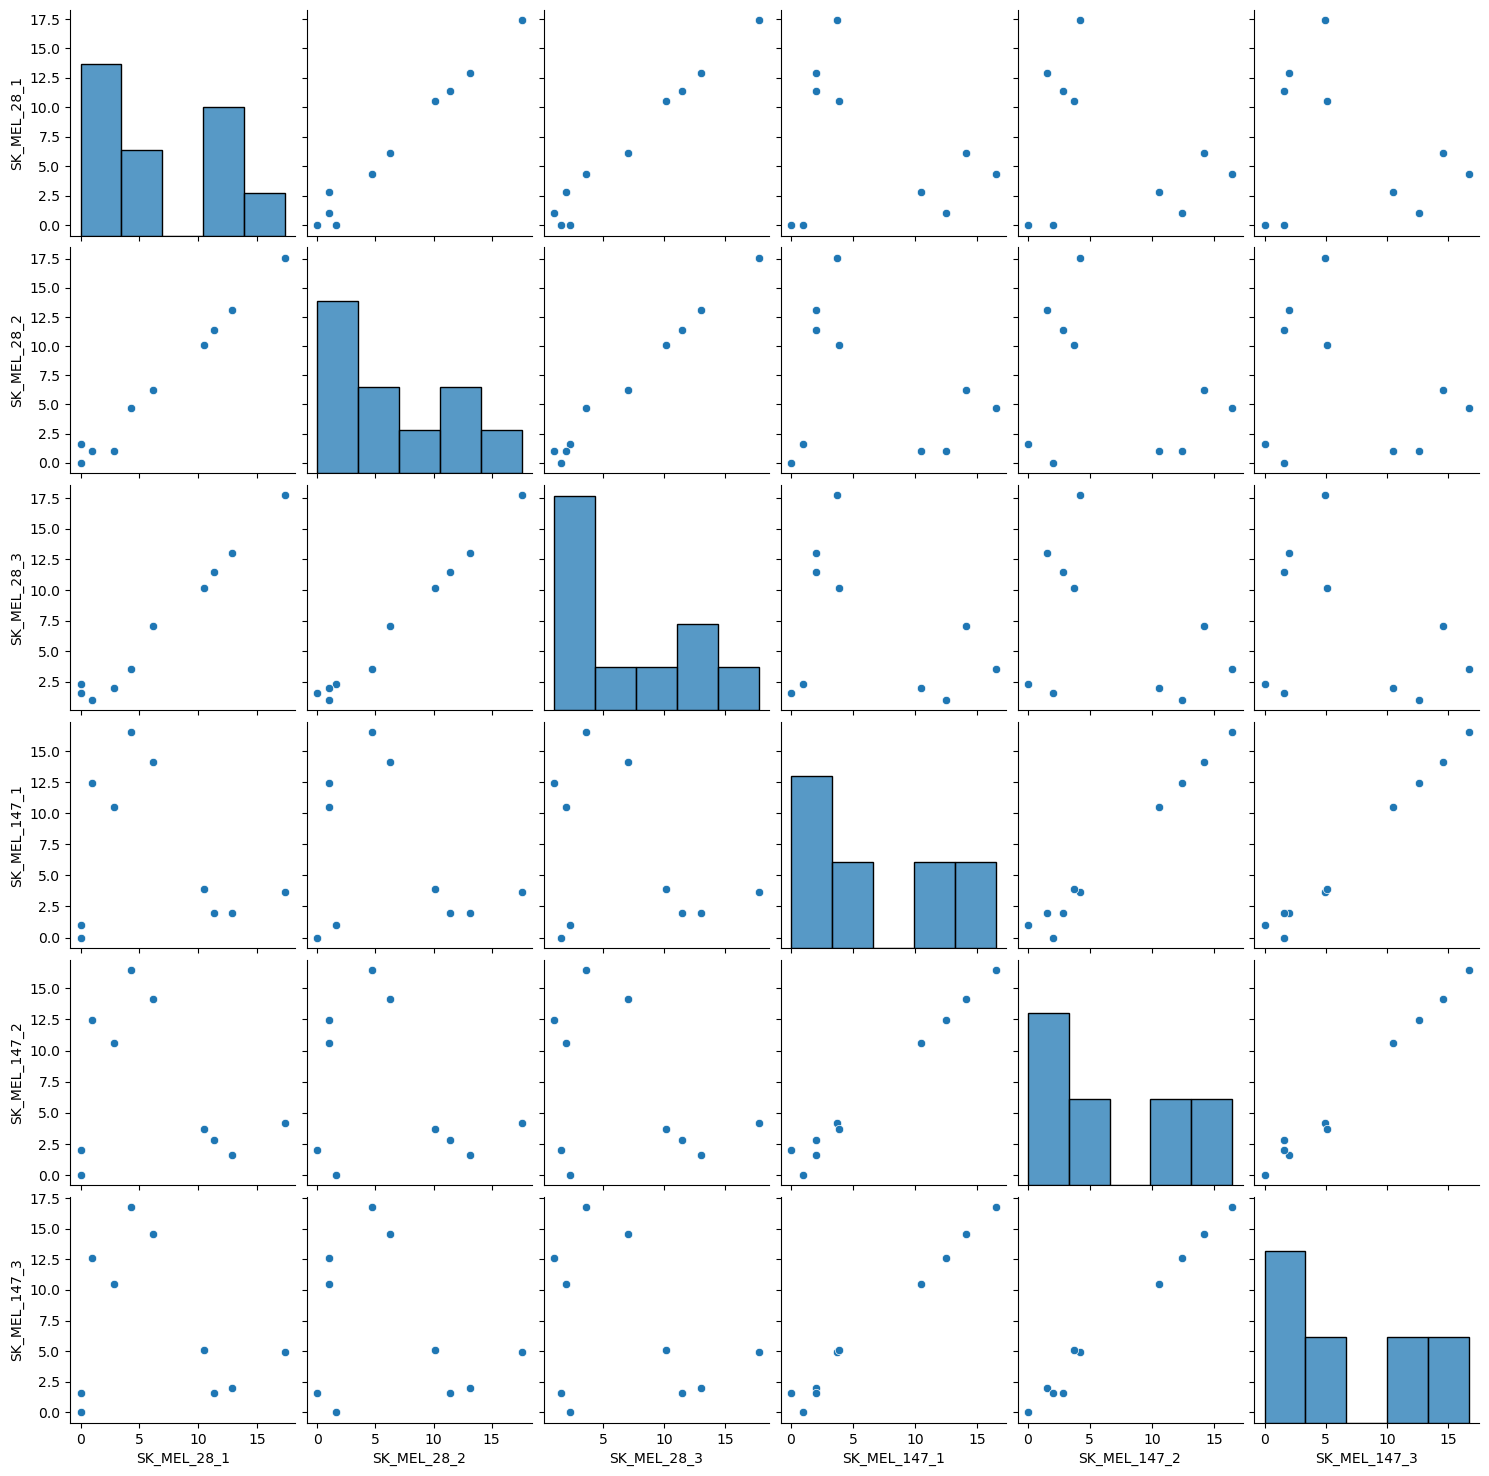

In [17]:
# Pairwise scatter plots for every combination of variables.
sns.pairplot(metastaticExp.loc[:'SK_MEL_147_3',topvarGens10].transpose());

This visualization approach gives a lot of information, but is very time-consuming to generate, and is sometimes hard to interpret.

### Heatmaps

Heatmaps are another way to visualize correlation outputs that are more condensed than the `pairplot` approach.


There are many packages that enable heatmap plotting, but today, we'll discuss `altair`, which enables some nice customization as well as interactive plot stitching.

In order to plot, `altair` expects the data to be organized such that each element belongs in a different column of a data frame (e.g. the x and y axis of the data need to be in separate columns).

Thus, we'll need to do some reshaping of our dataframe to make it compatible with `altair` expectations.

In [18]:
metatop10 = metastaticExp.loc[:,topvarGens10] # extracting the expression of the top 10 variably expressed genes for the metastatic samples
metatop10['SampleID'] = metatop10.index # adding a SampleID column. to the data frame. We'll need this for a later part of the plotting.
metatop10

,PMEL,TYRP1,AEBP1,GLUL,TYR,...,CDC42EP1,A2M,SOD3,TGFBI,SampleID
Sample Title,,,,,,,,,,,
SK_MEL_28_1,17.40,10.54,0.00,2.81,12.88,...,1.00,11.37,0.00,4.32,SK_MEL_28_1
SK_MEL_28_2,17.60,10.10,1.58,1.00,13.10,...,1.00,11.40,0.00,4.70,SK_MEL_28_2
SK_MEL_28_3,17.77,10.18,2.32,2.00,13.02,...,1.00,11.48,1.58,3.58,SK_MEL_28_3
SK_MEL_147_1,3.70,3.91,1.00,10.49,2.00,...,12.47,2.00,0.00,16.49,SK_MEL_147_1
SK_MEL_147_2,4.17,3.70,0.00,10.58,1.58,...,12.44,2.81,2.00,16.48,SK_MEL_147_2
SK_MEL_147_3,4.95,5.13,0.00,10.50,2.00,...,12.63,1.58,1.58,16.73,SK_MEL_147_3
UACC_62_1,6.43,6.98,0.00,0.00,12.77,...,2.00,14.71,13.37,7.42,UACC_62_1
UACC_62_2,5.17,5.78,1.58,0.00,12.66,...,1.00,13.34,12.77,8.14,UACC_62_2
UACC_62_3,5.46,4.81,1.58,0.00,12.32,...,2.32,13.56,12.45,8.73,UACC_62_3


Here's what we want to reshape the `metatop10` data frame to:

In [19]:
# cutting out the sampleID column, calculating the correlation matrix, reshaping the correlation
metatop10.drop('SampleID',axis = 1).corr().stack().reset_index().rename(columns={0: 'correlation'})

,level_0,level_1,correlation
0,PMEL,PMEL,1.00
1,PMEL,TYRP1,0.97
2,PMEL,AEBP1,0.33
3,PMEL,GLUL,-0.43
4,PMEL,TYR,0.61
...,...,...,...
95,TGFBI,EEF1A2,0.87
96,TGFBI,CDC42EP1,0.96
97,TGFBI,A2M,-0.87
98,TGFBI,SOD3,-0.17


Now for the heatmap plotting code

In [20]:
#default heatmap
heatmap = alt.Chart(
    metatop10.drop('SampleID',axis = 1).corr().stack().reset_index().rename(columns={0: 'correlation'}), # specifying the data to plot
).mark_rect().encode(
    x = alt.X('level_0'), # defining what will be on the x-axis,
    y = alt.Y('level_1'), # defining what will be on the y-axis
    color = alt.Color('correlation'), # defining the coloring options
)

heatmap

alt.Chart(...)

`altair` enables lots of customizations. Here are some examples

In [21]:
# Custom bins, different color scheme, custom legend and titles

heatmap = alt.Chart(
    metatop10.drop('SampleID',axis = 1).corr().stack().reset_index().rename(columns={0: 'correlation'}), # specifying the data to plot
    title='Correlation Heatmap',
    height=250,
    width=250,
).mark_rect().encode(
    x = alt.X('level_0').title('Sample 1'),
    y = alt.Y('level_1').title('Sample 2'),
    color = alt.Color('correlation',
                      scale=alt.Scale(scheme='blueorange'),  # changing the color palette
                      bin = alt.Bin(maxbins = 20), # changing the number of bins in the color palette
                      legend = alt.Legend(title='Pearson Correlation (binned)') # adding a custom title for the legend
                      ),


)

heatmap

alt.Chart(...)

For more information about color palettes, go [here](https://seaborn.pydata.org/tutorial/color_palettes.html).

`altair` also enables the addition of text onto the heatmap with an additional layer.

In [22]:
# Adding an extra layer of text
# Configure common options for both the heatmap and the text layer
base = alt.Chart(metatop10.drop('SampleID',axis = 1).corr().stack().reset_index().rename(columns={0: 'correlation'}).round(2), # source of the data
                  title='Correlation Heatmap',
                  height=250,
                  width=250,
                 ).encode(
                        x = alt.X('level_0').title('Sample 1'), # defining what will be on the x-axis
                        y = alt.Y('level_1').title('Sample 2'), # defining what will be on the y-axis

)

# Layering on the heatmap options
heatmap = base.mark_rect().encode(

    color = alt.Color('correlation',
                scale=alt.Scale(scheme='blueorange'),
                bin = alt.Bin(maxbins = 20),
                legend = alt.Legend(title='Pearson Correlation (binned)')
                ),

)

# Configure text
text = base.mark_text(baseline='middle',fontSize = 8).encode(
    text='correlation',
    color=alt.condition(
        alt.datum.correlation > -0.3,
        alt.value('black'),
        alt.value('yellow')
    )
)

# Draw the chart
heatmap + text

alt.LayerChart(...)

`altair` also has the benefit of enabling interactive plotting. In order to enable this, we'll also need to set up a different configuration of the `metatop10` data frame by using the `melt` method.

In [23]:
metatop10.melt(
        id_vars='SampleID',
        var_name='Gene',
        value_name='value',
    )

,SampleID,Gene,value
0,SK_MEL_28_1,PMEL,17.40
1,SK_MEL_28_2,PMEL,17.60
2,SK_MEL_28_3,PMEL,17.77
3,SK_MEL_147_1,PMEL,3.70
4,SK_MEL_147_2,PMEL,4.17
...,...,...,...
85,SK_MEL_147_2,TGFBI,16.48
86,SK_MEL_147_3,TGFBI,16.73
87,UACC_62_1,TGFBI,7.42
88,UACC_62_2,TGFBI,8.14


In [24]:
# Create heatmap with selection

# Configure common options for both the heatmap and the text layer
base1 = alt.Chart(metatop10.drop('SampleID',axis = 1).corr().stack().reset_index().rename(columns={0: 'correlation'}).round(2), # source of the data
                  title='Correlation Heatmap',
                  height=250,
                  width=250,
                 ).encode(
                        x = alt.X('level_0').title('Sample 1'), # defining what will be on the x-axis
                        y = alt.Y('level_1').title('Sample 2'), # defining what will be on the y-axis

)

# define selection critera
select_x = alt.selection_point(fields=['level_0'], name='select_x', value='PMEL')
select_y = alt.selection_point(fields=['level_1'], name='select_y', value='PMEL')

# Layering on the heatmap options
heatmap = base1.mark_rect().encode(

    color = alt.Color('correlation',
                scale=alt.Scale(scheme='blueorange'),
                bin = alt.Bin(maxbins = 20),
                legend = alt.Legend(title='Pearson Correlation (binned)')
                ),
    opacity=alt.when(select_x, select_y).then(alt.value(1)).otherwise(alt.value(0.5)),
).add_params(
    select_x, select_y
)

# Configure text
text = base1.mark_text(baseline='middle',fontSize = 8).encode(
    text='correlation',
    color=alt.condition(
        alt.datum.correlation > -0.3,
        alt.value('black'),
        alt.value('yellow')
    )
)


# Create chart with individual lines/timeseries
base2 = alt.Chart(
    metatop10.melt(
        id_vars='SampleID',
        var_name='Gene',
        value_name='value',
    ),
    title='Expression by Sample',
)
bars = base2.transform_filter(
    # If the Gene is not in the selected values, the returned index is -1
    'indexof(datum.Gene, select_x.level_0) !== -1'
   '| indexof(datum.Gene, select_y.level_1) !== -1'
).mark_circle(size = 60).encode(
    alt.X('SampleID'),
    alt.Y('value').title('Expression Value'),
    alt.Color('Gene').legend(orient='bottom-right', offset=-50).title('Gene')
)


# Layout the charts
bars | (heatmap + text)

alt.HConcatChart(...)

### <font color=blue>Optional Bonus hands on practice</font>

Extract the top 10 most variably expressed genes from melanoma_log2. Use for loops to calculate the pairwise Pearson correlation p-value between each of these 10 genes across the **metastatic samples**. Use an if-statement within the for-loop to report back which gene pairs are significantly correlated.

**Hints**:

1. The syntax to run a Pearson Correlation p-value is:

`corrP, pPearson = stats.pearsonr(normExp.iloc[0,:], normExp.iloc[1,:])`

where `pPearson` is the p-value associated with the pearson test.

2. Using an if-statement might help you to store information about the significant p-values, as in the example discussed above.

In [ ]:
#Reminders about existing variables that might be useful:
print(melanoma_log2.head())



In [ ]:
print(topvarGens10)

In [ ]:
# Extracting top 10 variably expressed genes from metastaticExp


In [ ]:
#Setting up for loop for pairwise Pearson correlation p-value calculations and testing for significance




In [ ]:
# Create a data frame containing all the relevant variables
